In [425]:
import duckdb
import pandas as pd
from pathlib import Path
import diskcache
from itertools import chain
from collections import Counter

import igraph as ig
import matplotlib.pyplot as plt
import seaborn.objects as so
import seaborn as sns

from utils.pandas_setup import pandas_setup
pandas_setup()

import pyalex
from pyalex import Works, Authors, Sources, Institutions, Topics, Publishers, Funders
pyalex.config.email = "Lawrence.Cram@anu.edu.au"
pyalex.config.max_retries = 0
pyalex.config.retry_backoff_factor = 0.1
pyalex.config.retry_http_codes = [429, 500, 503]

MY_DATA_PATH = Path('../DATA/')
MY_DATABASE_FILE = Path(MY_DATA_PATH / 'econ.duckdb')
MY_CACHE_FILE = Path('/home/lc/m/.cache/econommicsbusiness/cache.db')
DATAFILES_PATH = Path('../DATAFILES')

In [426]:
class SetUp:

    def __init__(self):
        self._setup_db()
        self._setup_cache()
        return
    
    def _setup_db(self):
        self.db = duckdb.connect(MY_DATABASE_FILE)
        self.db.sql("ATTACH IF NOT EXISTS ':memory:'")
        self.db.sql(""" SET memory_limit = '56GB';
                        SET threads = 6;
                        SET preserve_insertion_order = false;
                        SET order_by_non_integer_literal=true;
                        SET enable_progress_bar = true;
                        SET temp_directory = '/home/lc/m/.tmp';
                    """)
        self.db.sql("SHOW ALL TABLES").show()
        return
    
    def _setup_cache(self):
        self.cache = diskcache.Cache(MY_CACHE_FILE, size_limit=16_000_000_000)
        print(f'{self.cache.check() = }')
        print(f'{self.cache.volume() = }')
        return
    
    def name_of_global_obj(self, obj=None):
        for objname, oid in globals().items():
            if oid is obj:
                return objname
            

In [427]:
class CoauthorshipNetwork(SetUp):

    def __init__(self):
        super().__init__()
        return
    
    def build_authorship_network(self):
        # get works from a few small, top  journals
        source_list = 'https://openalex.org/S2764736659 https://openalex.org/S7397502'
        sql = f"""
                CREATE OR REPLACE TABLE memory.network AS 
                    SELECT replace(source_id, 'https://openalex.org/', '') AS source_id,
                            -- any_value(source_name),
                            replace(institution_id, 'https://openalex.org/', '') AS institution_id,
                            -- any_value(institution_name)
                            count(work_id) AS weight,
                        FROM works w
                        LEFT JOIN authorships a
                            USING (work_id) 
                            WHERE contains('{source_list}', w.source_id) = true 
                                    AND author_name NOT NULL
                                    AND work_id NOT NULL
                        GROUP BY source_id, institution_id, source_name, institution_name
                        ORDER BY weight DESC, source_name, institution_name
            """
        self.db.sql(sql)
        self.db.sql("SELECT * FROM memory.network").show()
        self.db.sql("COPY memory.network TO '../DATA/NETWORK_DATA/trial.csv' (HEADER false, DELIMITER '\t')")
        return
    
    def extract_graph(self):
        self.g = ig.Graph.Read_Ncol('../DATA/NETWORK_DATA/trial.csv', names=True)
        print(self.g.get_edgelist())
        print(self.g.es["weight"])
        print(self.g.vs["name"])
        return
    
    def pagerank(self):
        ranks = self.g.pagerank()
        print(ranks)
        return


### This class constructs the pageRank for sources linked by citation counts

-  build the edge list of journal (citer) -> journal (cited)  
-  construct an iGraph from the edge list  
-  run pageRank  
-  for each author, calculate the number of ciations and the number of citations weighted by the pageRank of the citing journal



In [428]:
class PageRanks(SetUp):

    def __init__(self):
        super().__init__()
        return

    def vertex_labels(self):
        sql = """
            SELECT DISTINCT source_id AS id,
                    source_name AS name
                FROM works
            UNION
            SELECT DISTINCT institution_id AS id,
                    institution_name AS name
                from authorships
            """
        df = self.db.sql(sql).df()
        self.vertex_labels = dict(zip(df.id, df.name))
        return
    
    def make_edge_lists(self):
        # SQL code to assemble the edge list with the count of work-work citations as weights
        sql = """
            CREATE OR REPLACE TABLE econ.edge_list_combined AS

                WITH 
                source_cte AS
                    (SELECT w.work_id, w.source_id, 1.0 AS weight FROM
                    (SELECT count(work_id) AS counts, source_id FROM econ.works GROUP BY ALL) sub
                    LEFT JOIN econ.works w
                    USING (source_id)
                    WHERE sub.counts > 100
                    ORDER BY sub.counts DESC
                    ),
                institution_part_cte AS
                    (SELECT institution_id, 1.0 AS weight FROM
                    (SELECT count(work_id) AS counts, institution_id FROM
                        (SELECT DISTINCT work_id, institution_id FROM econ.authorships)
                        GROUP BY ALL
                    )
                    WHERE counts > 100 AND institution_id NOT NULL
                    ORDER BY counts DESC
                    ),
                institution_weight_cte AS
                    (SELECT DISTINCT a.work_id, 1.0/count(i.institution_id) AS weight
                    FROM institution_part_cte i
                    LEFT JOIN econ.authorships a
                    ON a.institution_id = i.institution_id
                    WHERE a.institution_id NOT NULL
                    GROUP BY ALL
                    ),
                institution_cte AS
                    (SELECT a.work_id, a.institution_id, iw.weight
                    FROM institution_weight_cte iw
                    LEFT JOIN econ.authorships a
                    USING (work_id)
                    ),
                works_sources_institutions AS
                    (
                    SELECT DISTINCT work_id, source_id AS item, weight
                    FROM source_cte
                    UNION
                    SELECT DISTINCT work_id, institution_id AS item, weight
                    FROM institution_cte
                    ORDER BY work_id ASC, item ASC
                    ),
                citations AS
                    (SELECT work_id AS citer_id, unnest(referenced_works) AS cited_id FROM econ.cited),
                full_table AS
                    (SELECT citer_id, w1.item AS citer_item, w1.weight AS citer_weight,
                        cited_id, w2.item AS cited_item, w2.weight AS cited_weight 
                    FROM citations c
                        LEFT JOIN works_sources_institutions w1
                        ON c.citer_id = w1.work_id
                        LEFT JOIN works_sources_institutions w2
                        ON c.cited_id = w2.work_id
                        WHERE citer_item NOT NULL AND cited_item NOT NULL
                    ORDER BY citer_id, citer_item, citer_weight, cited_id)

                -- SELECT * FROM citations
                -- SELECT * FROM source_cte
                -- SELECT count(DISTINCT work_id), count(DISTINCT source_id) FROM source_cte
                -- SELECT * FROM institution_cte
                -- SELECT count(DISTINCT institution_id) FROM institution_part_cte
                -- SELECT count(DISTINCT work_id), count(DISTINCT institution_id) FROM institution_cte
                -- SELECT * FROM works_sources_institutions

                SELECT citer_item, cited_item, sum(citer_weight) AS weights
                FROM full_table
                GROUP BY citer_item, cited_item
        """
        self.db.sql(sql)
        return
    
    def load_edge_lists(self):
        sql = """
                CREATE OR REPLACE TABLE econ.edge_list_sources AS
                SELECT * FROM econ.edge_list_combined
                WHERE contains(citer_item, '/S') AND contains(cited_item, '/S')
                ORDER BY weights DESC;

                CREATE OR REPLACE TABLE econ.edge_list_institutions AS
                SELECT * FROM econ.edge_list_combined
                WHERE contains(citer_item, '/I') AND contains(cited_item, '/I')
                ORDER BY weights DESC;

                CREATE OR REPLACE TABLE econ.edge_list_both AS
                SELECT * FROM econ.edge_list_combined
                --WHERE contains(citer_item, '/I') AND contains(cited_item, '/I')
                ORDER BY weights DESC;
            """
        self.db.sql(sql)
        return
    
    def _extract_edge_list(self):
        match self.kind:
            case 'sources':
                cut = '/S'
            case 'institutions':
                cut = '/I'
            case 'both':
                cut = 'http'
        return self.db.sql(f"SELECT * FROM econ.edge_list_combined WHERE contains(citer_item, '{cut}') = true AND contains(cited_item, '{cut}') = true").df()

    def construct_graph(self, kind=None):
        self.kind = kind
        df_edges = self._extract_edge_list()
        print(f'{df_edges.shape = }\n{df_edges.head()}\n{df_edges.tail()}')
        vertices = set(df_edges.citer_item.tolist() + df_edges.cited_item.tolist())
        vs = pd.DataFrame(data=list(vertices), columns=['id'])
        vs['label'] = [self.vertex_labels.get(id) for id in vs.id]
        print(f'{vs.shape = }\n{vs.head()}')
        self.g = ig.Graph.DataFrame(df_edges, directed=True, use_vids=False, vertices=vs)
        summary = ig.summary(self.g, verbosity=1, width=256, edge_list_format='auto', max_rows=2, print_graph_attributes=True, 
                                          print_vertex_attributes=True, print_edge_attributes=True, full=False)
        print(f'*** SUMMARY OF self.g\n{summary}')
        return
    
    def run_pagerank(self):
        print('pageRank')
        damping = 0.85 if self.kind == 'both' else 0.85
        print(f'>> RUN pagerank with {damping = } for {self.kind = }')
        ranks = self.g.pagerank(damping=damping, weights='weights', implementation='prpack')
        print(f'>> CHECK pageRank  - should sum to unity {sum(ranks) = }')
        rank_max = max(ranks)
        ranks = [r/rank_max for r in ranks]
        self.pagerank = pd.DataFrame(zip(ranks, self.g.vs["name"], self.g.vs['label'], self.g.strength(mode='in', loops=False, weights='weights')),
                                      columns=['pageRank','citer', 'label', 'cite_count']).sort_values('pageRank', ascending=False)
        df = self.pagerank
        self.db.sql(f"CREATE OR REPLACE TABLE econ.pagerank_{self.kind} AS SELECT * FROM df")
        return
    
    def report_pagerank(self):
        kind = self.kind
        print(f'report pagerank {kind = }')
        df = self.db.sql(f"SELECT * FROM econ.pagerank_{kind}").df().sort_values('pageRank', ascending=False).reset_index(drop=True)        
        if self.kind == 'both':
            print(f'  Both df\n{df.head()}')
        elif self.kind == 'sources':
            print(f'  Source df\n{df[df.citer.str.contains('/S')].head()}')
        else:
            print(f'  Institutions df\n{df[df.citer.str.contains('/I')].head()}')           
        print(f'Sum of citations {df['cite_count'].sum() = }')
        print(f'Sum of scaled pageranks {df['pageRank'].sum() = }')
        self.db.sql("SELECT count(DISTINCT work_id) AS original_works_count FROM works").show()
        return
    


In [429]:

class WeightedCitationCounts(SetUp):

    def __init__(self):
         super().__init__()
         return
    
    def make_weighted_citations(self):

        for kind in ['sources', 'institutions', 'both']:
            sql = f"""
                CREATE OR REPLACE TABLE econ.weighted_citations_{kind} AS
                    WITH 
                    item_cte AS
                        (SELECT DISTINCT citer_item
                        FROM econ.edge_list_combined
                        ), -- cte to filter combined list
                    source_cte AS
                        (SELECT citer_item AS source_id
                        FROM item_cte
                        WHERE contains(citer_item, '/S') = true
                        ), -- cte to filter sources from combined list
                    institution_cte AS
                        (SELECT citer_item AS institution_id
                        FROM item_cte
                        WHERE contains(citer_item, '/I') = true
                        ), -- cte to filter institutions     p = Plotters()
                    works_sources_institutions AS
                        (
                        SELECT DISTINCT w.work_id, w.source_id, a.institution_id
                        FROM econ.works w
                        LEFT JOIN econ.authorships a
                        USING (work_id)
                        LEFT JOIN source_cte s
                        ON s.source_id = w.source_id
                        LEFT JOIN institution_cte i
                        ON i.institution_id = a.institution_id
                        WHERE a.institution_id NOT NULL AND w.source_id NOT NULL
                        ORDER BY w.source_id, a.institution_id
                        ), -- cte to build a table of the sources (one-to-one) and institutions (one-to-many) for each work 
                    work_pagerank_sources AS
                        (
                        SELECT DISTINCT w.work_id, pageRank
                        FROM works_sources_institutions w
                        LEFT JOIN pagerank_sources p
                        ON w.source_id = p.citer
                        ), -- cte to attach source-only pageranks to works
                    work_pagerank_institutions AS
                        (
                        SELECT DISTINCT w.work_id, sum(pageRank)/count(pagerank) AS pagerank
                        FROM works_sources_institutions w
                        LEFT JOIN pagerank_institutions p
                        ON w.institution_id = p.citer
                        GROUP BY ALL
                        ), -- cte to attach institution-only averaged pagerank to works
                    work_pagerank_both AS
                        (SELECT sub.work_id, 0.5*(sub.pagerank + p1.pagerank) AS pageRank
                        FROM
                            (
                                SELECT w.work_id, w.source_id, sum(pageRank)/count(pageRank) AS pagerank
                                FROM works_sources_institutions w
                                LEFT JOIN pagerank_both p
                                ON w.institution_id = p.citer
                                GROUP BY ALL
                            ) sub
                            LEFT JOIN pagerank_both p1
                            ON sub.source_id = p1.citer
                        ), -- cte to attach avergaeed (source and average institution) pagerank to works
                    citer_cited AS
                        (
                        SELECT work_id AS citer_id, unnest(referenced_works) AS cited_id
                        FROM cited
                        ), -- cte to make citer-cited relation
                    citers_authors AS
                        (
                        SELECT DISTINCT author_id, c.citer_id
                        FROM econ.authorships a
                        LEFT JOIN citer_cited c
                        ON a.work_id = c.cited_id
                        )  -- cte to build a list of citer works for each author 
                    
                    --SELECT * FROM item_cte
                    -- SELECT * FROM works_sources_institutions
                    -- SELECT * FROM citer_cited
                    -- SELECT * FROM citers_authors
                    -- SELECT * FROM work_pagerank_sources
                    -- SELECT * FROM work_pagerank_institutions
                    -- SELECT * FROM work_pagerank_both

                    SELECT author_id, count(DISTINCT citer_id) AS citer_count, sum(pagerank) AS citer_count_weighted
                    FROM
                        (SELECT c.citer_id, c.author_id, pagerank
                        FROM citers_authors c
                        LEFT JOIN work_pagerank_{kind} w
                        ON c.citer_id = w.work_id
                        WHERE pagerank NOT NULL)
                    GROUP BY ALL
                    ORDER BY citer_count DESC

            """
            self.db.sql(sql)
            self.db.sql(f"SELECT * FROM econ.weighted_citations_{kind} ORDER BY citer_count DESC").show()
        return



In [430]:
class Plotters(SetUp):

    def __init__(self):
        super().__init__()
        return


    def plot_pagerank(self):
        df_s = self.db.sql("""
                    SELECT 'Source' AS linker, s.pageRank AS 'pageRank uncoupled', b.pageRank AS 'pageRank coupled' 
                           FROM pagerank_sources s LEFT JOIN pagerank_both b ON s.label = b.label"""
                           ).df()
        df_i = self.db.sql("""
                    SELECT 'Institution' AS linker, s.pageRank AS 'pageRank uncoupled', b.pageRank AS 'pageRank coupled' 
                           FROM pagerank_institutions s LEFT JOIN pagerank_both b ON s.label = b.label"""
                           ).df()
        df = pd.concat([df_s, df_i], axis=0).reset_index(drop=True)
        print(f'{df_s.shape = }\n{df_s.head()}')
        print(f'{df_i.shape = }\n{df_i.head()}')
        fig, ax = plt.subplots(1, 1)
        sns.scatterplot(df, x='pageRank uncoupled', y='pageRank coupled', hue='linker')
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_xlim((0.001, 1.0))
        ax.set_ylim((0.001, 1.0))
        plt.show()
        return
    
    def plot_citatation_weights(self):
        drop_small_edge_weights = 0  # drop edges with small weights
        boost_institution_weights = 1.0 # amplify the institution-institution counts to roughly match journal counts
        clip_institution_table = 2000
        print(f'CONDITION edge list: {clip_institution_table = } {boost_institution_weights = } {drop_small_edge_weights = }')
        
        self.db.sql("SELECT * FROM weighted_citations_institutions").show()
        self.db.sql("SELECT * FROM weighted_citations_sources").show()
        
        df = self.db.sql(f"""
            SELECT 'Source' AS kind, s.citer_count_weighted AS 'Citation weight',
                FROM weighted_citations_sources s
                WHERE s.citer_count_weighted > {drop_small_edge_weights}
            UNION
            (SELECT 'Institution' AS kind, {boost_institution_weights}*i.citer_count_weighted AS 'Citation weight'
                FROM weighted_citations_institutions i
                WHERE citer_count_weighted > {drop_small_edge_weights}
                LIMIT {clip_institution_table})
            """).df().dropna()
        print(df.groupby('kind').describe())
        df = df[df['Citation weight']>20]
        print(f'{df.shape = }\n{df.head(32)}')
        fig, ax = plt.subplots(1, 1)
        sns.histplot(df, x='Citation weight', hue='kind', stat='count', bins=100, binrange=(1, 200), common_bins=True, cumulative=True)
        ax.set_title("Cumulate over authors of citation counts versus citation weight")
        plt.show()
        return     

    def plot_model(self, kind=None):
        df = self._extract_data(kind=kind)
        df = self.db.sql(f"SELECT * FROM econ.weighted_citations_{kind}").df().sort_values('citer_count_weighted', ascending=False)
        df = df.dropna()

        sample = self.db.sql("SELECT * FROM econ.sample_names").df()
        dd_group = dict(zip(sample.author_id, sample.Group))
        dd_name = dict(zip(sample.author_id, sample.author_name))
        print(f'{df.author_id.nunique() = }')

        # Scale author citation weights so that the least down-scaled match the unweighted for the higher citation authors
        df.insert(2, 'ratio', [x/y for x, y in zip(df.citer_count_weighted, df.citer_count)])
        ratio_scale = 10.0
        print(f'MAX ratio of weighted to unweighted citations {ratio_scale = }')
        df['citer_count_weighted'] = df.citer_count_weighted*ratio_scale

        df['author_name'] = [dd_name.get(aid) for aid in df.author_id]
        df['group'] = [dd_group.get(aid, 'X') for aid in df.author_id]
        df['pointsize'] = [0.01 if g == 'X' else 10 for g in df.group]
        
        df = df.sort_values(['group', 'pointsize'], ascending=[False, True])
        fig, ax = plt.subplots(1, 1)
        sns.scatterplot(df, x='citer_count', y='citer_count_weighted', hue='group', size='pointsize')
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_xlim((10, 10000))
        ax.set_ylim((10, 10000))
        hand, lab = ax.get_legend_handles_labels()
        lab[0] = 'Group'
        ax.legend()
        ax.legend(handles=list(hand[:4]), labels=list(lab[:4]), loc=2)
        ax.set_title(f'{kind.title()} citing {kind}')
        plt.show()

        df = df[df.group != 'X']
        df = df[['citer_count_weighted', 'citer_count', 'ratio', 'author_name', 'group']].sort_values('ratio', ascending=False).reset_index(drop=True)
        df.to_csv(f'../DATA/weighted_citations_{kind}.csv')

        return
    
    def plot_deficit(self, kind=None):
        df = self.db.sql(f"SELECT * FROM econ.weighted_citations_{kind}").df().sort_values('citer_count_weighted', ascending=False)
        df = df.dropna()
        df = df[df.citer_count > 100]
        sample = self.db.sql("SELECT * FROM econ.sample_names").df()
        dd = dict(zip(sample.author_id, sample.Group))


        df['reputation %'] = [w/c for w, c in zip(df.citer_count_weighted, df.citer_count)]
        df['reputation %'] = df['reputation %']*100//max(df['reputation %'])
        print(df.sort_values('reputation %', ascending=False).head(8))
        df['group'] = [dd.get(aid, 'X') for aid in df.author_id]
        df['pointsize'] = [0.01 if g == 'X' else 10 for g in df.group]
        df = df.sort_values(['group', 'pointsize'], ascending=[False, True])

        fig, ax = plt.subplots(1, 1)
        sns.scatterplot(df, x='citer_count', y='reputation %', hue='group', size='pointsize')
        # ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_xlim((100, 20000))
        ax.set_ylim((0, 100))
        hand, lab = ax.get_legend_handles_labels()
        lab[0] = 'Group'
        ax.legend()
        ax.legend(handles=list(hand[:4]), labels=list(lab[:4]), loc='upper right')
        ax.set_title(f'{kind.title()} citing {kind}')
        plt.show()

        return
    
    def plot_hca(self, kind=None):
        df = self._extract_data(kind=kind).sort_values('citer_count_weighted', ascending=False)
        df = df.dropna()
        df = df[df.citer_count > 100]
        sample = self.db.sql("SELECT * FROM econ.sample_names").df()
        dd = dict(zip(sample.author_id, sample.Group))

        df['reputation %'] = [w/c for w, c in zip(df.citer_count_weighted, df.citer_count)]
        df['reputation %'] = df['reputation %']*100//max(df['reputation %'])
        print(df.sort_values('reputation %', ascending=False).head(8))
        df['group'] = [dd.get(aid, 'X') for aid in df.author_id]
        df['pointsize'] = [0.01 if g == 'X' else 10 for g in df.group]
        df = df.sort_values(['group', 'pointsize'], ascending=[False, True])

        fig, ax = plt.subplots(1, 1)
        ax.legend()
        sns.scatterplot(df, x='citer_count', y='reputation %', style='group', palette='Spectral_r', hue='hca_endogenous', size='pointsize')
        # ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_xlim((500, 10000))
        ax.set_ylim((0, 100))
        hand, lab = ax.get_legend_handles_labels()
        print(hand,lab)
        lab[0] = 'HCA'
        ax.legend()
        new_hand = hand
        new_lab = lab
        ax.legend(handles=list(new_hand), labels=list(new_lab), loc='upper right')
        ax.set_title(f'{kind.title()} citing {kind}')
        plt.show()

        return
    
    def _extract_data(self, kind=None):
        sql = f"""
            SELECT w.*, CASE WHEN s.hca_endogenous IS NULL THEN 0 ELSE s.hca_endogenous END AS hca_endogenous
                FROM econ.weighted_citations_{kind} w
                LEFT JOIN econ.citation_summary s
                USING (author_id)
                ORDER BY hca_endogenous DESC
            """
        self.db.sql(sql).show()
        return self.db.sql(sql).df()


In [431]:
def main():

    # cn = CoauthorshipNetwork()
    # cn.build_authorship_network()
    # cn.extract_graph()
    # cn.pagerank()

    # pr = PageRanks()
    # pr.vertex_labels()
    # pr.make_edge_lists()
    # pr.load_edge_lists()
    # for kind in ['sources', 'institutions', 'both']:
    #     pr.construct_graph(kind=kind)
    #     pr.run_pagerank()
    #     pr.report_pagerank()

    # cn = WeightedCitationCounts()
    # cn.make_weighted_citations()

    p = Plotters()
    # p.plot_pagerank()
    # p.plot_citatation_weights()
    # for kind in ['sources', 'institutions', 'both']:
        # p.plot_model(kind=kind)
        # p.plot_deficit(kind=kind)
    p.plot_hca(kind='both')

┌──────────┬─────────┬─────────────────────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

/tmp/ipykernel_1285218/1162409259.py:142: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[<matplotlib.lines.Line2D object at 0x7337e1296a50>, <matplotlib.lines.Line2D object at 0x7337d8160d40>, <matplotlib.lines.Line2D object at 0x7337d8161ca0>, <matplotlib.lines.Line2D object at 0x7337d8161e50>, <matplotlib.lines.Line2D object at 0x7337d8163b90>, <matplotlib.lines.Line2D object at 0x7337d8161460>, <matplotlib.lines.Line2D object at 0x7337d8162510>, <matplotlib.lines.Line2D object at 0x7337a471bc80>, <matplotlib.lines.Line2D object at 0x7337a4718890>, <matplotlib.lines.Line2D object at 0x7337a471a9f0>, <matplotlib.lines.Line2D object at 0x7337a471a090>, <matplotlib.lines.Line2D object at 0x7337a47181d0>, <matplotlib.lines.Line2D object at 0x7337d81c23f0>, <matplotlib.lines.Line2D object at 0x7337a47187d0>, <matplotlib.lines.Line2D object at 0x7337a47198e0>] ['hca_endogenous', '0', '6', '12', '18', '24', '30', '36', 'pointsize', '0.01', '10.0', 'group', 'X', 'T', 'C']


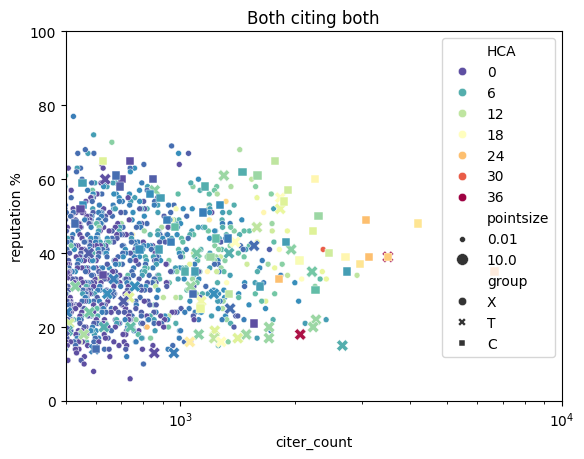

DONE!


In [432]:
if __name__ == "__main__":
    main()
    print("DONE!")